# Compose multi-panel figures

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
import string
from PIL import Image

## genome_wide_rates.png

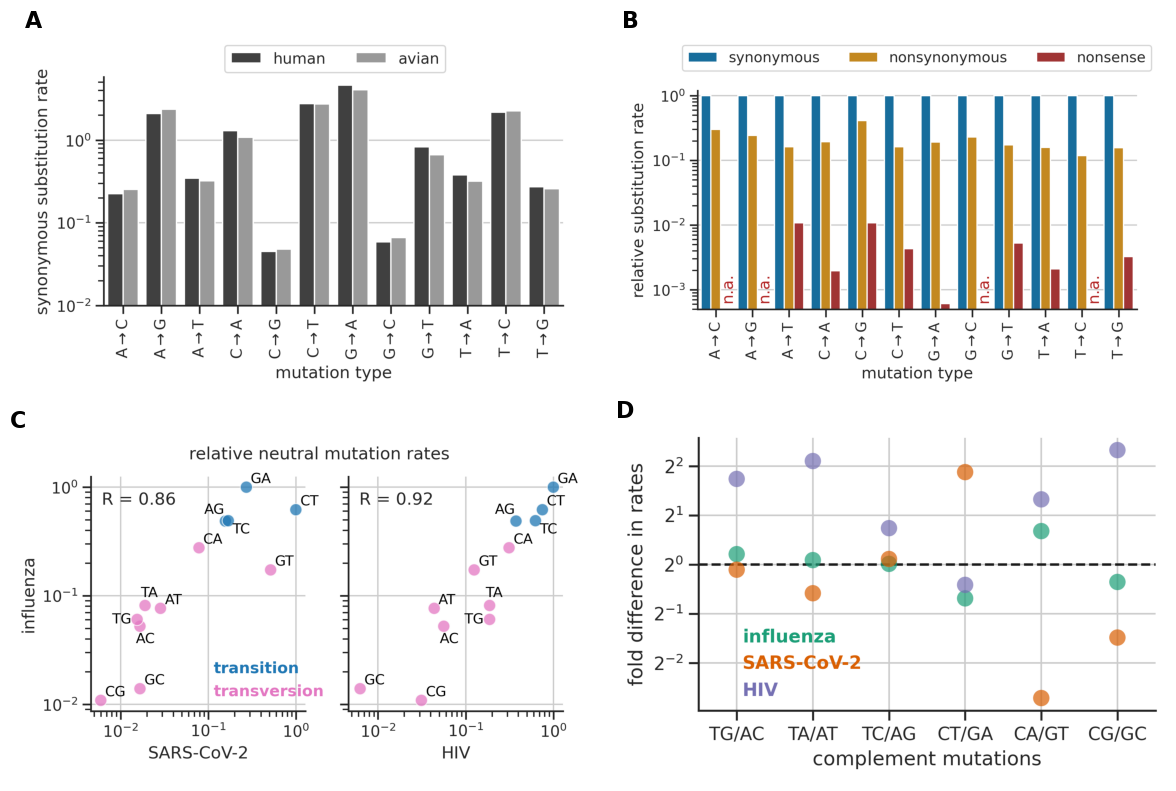

In [2]:
# Paths to the four panel PNGs
panel_paths = [
    "../results/figures/genome_wide_synonymous_rates.png",
    "../results/figures/genome_wide_mut_class_rates.png",
    "../results/figures/genome_wide_rates_comparison.png",
    "../results/figures/genome_wide_fold_differences.png",
]

# Load images
panels = [mpimg.imread(p) for p in panel_paths]

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, img, label in zip(axes.flat, panels, string.ascii_uppercase):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(label, fontsize=16, fontweight="bold", loc="left")

plt.tight_layout()
plt.savefig("../results/figures/genome_wide_composite.png", dpi=300, bbox_inches="tight")
plt.show()

In [3]:
# Resize genome_wide_composite to 6 inches wide, preserving aspect ratio and DPI
dpi = 300
target_width_in = 6
img = Image.open("../results/figures/genome_wide_composite.png")
new_width_px = int(target_width_in * dpi)
scale = new_width_px / img.width
new_height_px = int(img.height * scale)
img_resized = img.resize((new_width_px, new_height_px), Image.LANCZOS)
img_resized.save("../results/figures/ms_figures/genome_wide_rates.png", dpi=(dpi, dpi))
print(f"Resized to {new_width_px}x{new_height_px} px ({target_width_in}x{new_height_px/dpi:.1f} in at {dpi} DPI)")

Resized to 1800x1208 px (6x4.0 in at 300 DPI)


## site_specific_rates.png

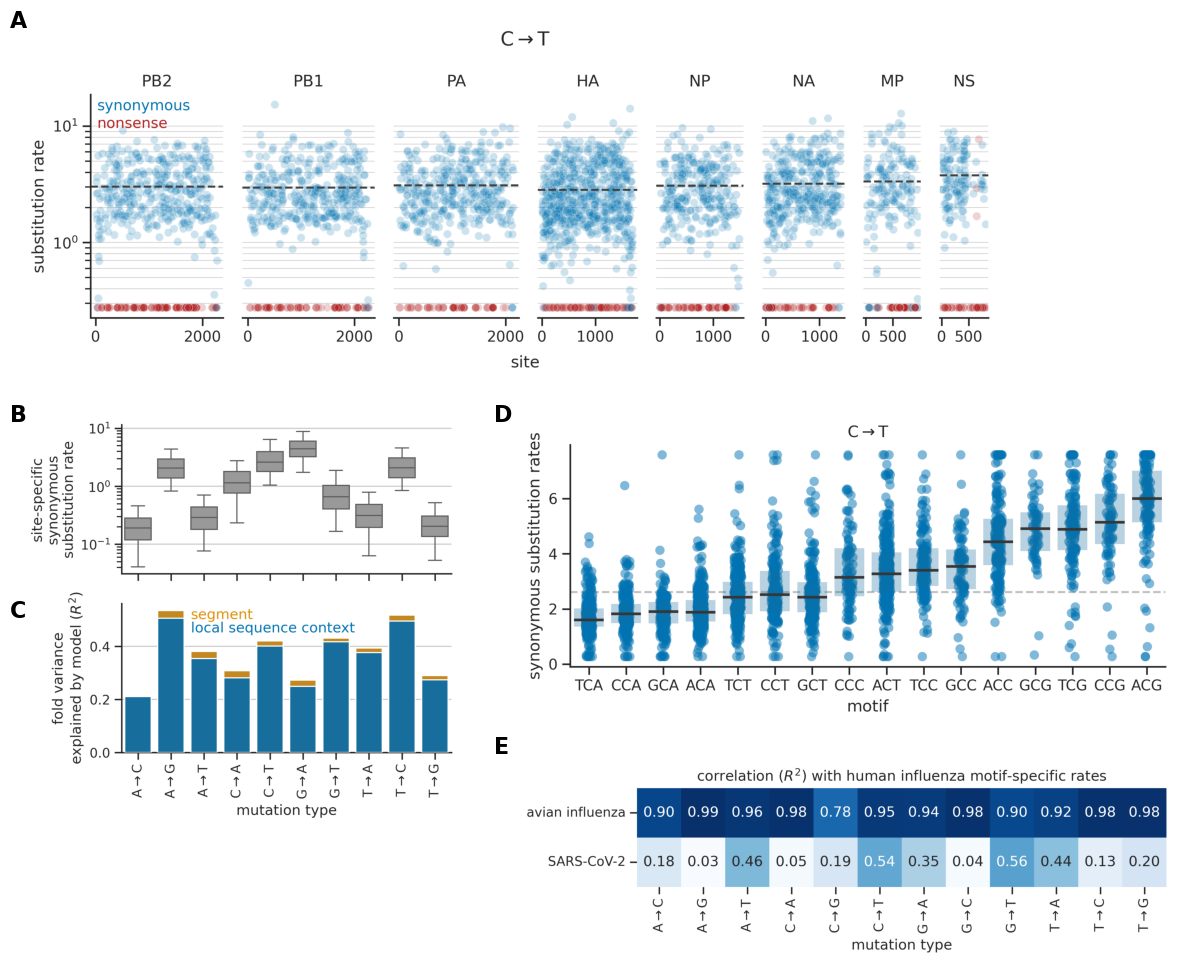

In [4]:
# Load images
img_a = mpimg.imread("../results/figures/mut_rates_C_T.png")
img_bc = mpimg.imread("../results/figures/site_specific_rates_spread.png")
img_d = mpimg.imread("../results/figures/CT_motif_specific_rates.png")
img_e = mpimg.imread("../results/figures/motif_specific_correlations.png")

# Layout: 3 rows x 2 columns
# Row 0: A spans both columns (full width)
# Rows 1-2, col 0: B/C (single tall image)
# Row 1, col 1: D
# Row 2, col 1: E
width_ratios = [2, 3]
right_frac = width_ratios[1] / sum(width_ratios)

# Compute height ratios in consistent units (rendered height per unit figure width).
# A uses full width; D and E use right-column width.
a_h = img_a.shape[0] / img_a.shape[1]
d_h = (img_d.shape[0] / img_d.shape[1]) * right_frac * 0.65
e_h = (img_e.shape[0] / img_e.shape[1]) * right_frac
height_ratios = [a_h * 0.55, d_h, e_h]

fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(
    3, 2,
    height_ratios=height_ratios,
    width_ratios=width_ratios,
    hspace=0.105,
    wspace=0.04,
    left=0.05,
    right=0.98,
    top=0.98,
    bottom=0.08,
)

# A: top row, spans both columns
ax_a = fig.add_subplot(gs[0, :])
ax_a.imshow(img_a)
ax_a.axis("off")
ax_a.set_anchor("NW")
pos_a = ax_a.get_position()
ax_a.set_position([pos_a.x0 - 0.03, pos_a.y0, pos_a.width, pos_a.height])

# B/C: left column, spans rows 1-2
ax_bc = fig.add_subplot(gs[1:, 0])
ax_bc.imshow(img_bc)
ax_bc.axis("off")
ax_bc.set_anchor("NW")
pos_bc = ax_bc.get_position()
ax_bc.set_position([pos_bc.x0 - 0.03, pos_bc.y0, pos_bc.width, pos_bc.height])

# D: row 1, right column — anchor top to align with B
ax_d = fig.add_subplot(gs[1, 1])
ax_d.imshow(img_d)
ax_d.axis("off")
ax_d.set_anchor("N")

# E: row 2, right column — anchor top, then shift up to meet D
ax_e = fig.add_subplot(gs[2, 1])
ax_e.imshow(img_e)
ax_e.axis("off")
ax_e.set_anchor("N")

# Calculate D's rendered image bottom in figure coords
pos_d = ax_d.get_position()
d_rendered_h = pos_d.width * (img_d.shape[0] / img_d.shape[1])
d_img_bottom = pos_d.y1 - d_rendered_h

# Move E below D with a small gap
pos_e = ax_e.get_position()
new_e_y1 = d_img_bottom - 0.03
new_e_y0 = new_e_y1 - pos_e.height
ax_e.set_position([pos_e.x0, new_e_y0, pos_e.width, pos_e.height])

# Panel labels: A, B, C all at the same fixed x in figure coords.
label_kwargs = dict(fontsize=16, fontweight="bold", va="top", ha="left")
label_x = 0.01

pos_a = ax_a.get_position()
pos_bc = ax_bc.get_position()

fig.text(label_x, pos_a.y1 + 0.01, "A", **label_kwargs)
fig.text(label_x, pos_bc.y1 + 0.01, "B", **label_kwargs)
fig.text(label_x, pos_bc.y0 + 0.55 * (pos_bc.y1 - pos_bc.y0), "C", **label_kwargs)

pos_d = ax_d.get_position()
fig.text(pos_d.x0 - 0.02, pos_d.y1 + 0.01, "D", **label_kwargs)

pos_e = ax_e.get_position()
fig.text(pos_e.x0 - 0.02, pos_e.y1 + 0.02, "E", **label_kwargs)

plt.savefig(
    "../results/figures/site_specific_rates_composite.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [5]:
# Resize site_specific_rates_composite to 7 inches wide, preserving aspect ratio and DPI
dpi = 300
target_width_in = 7
img = Image.open("../results/figures/site_specific_rates_composite.png")
new_width_px = int(target_width_in * dpi)
scale = new_width_px / img.width
new_height_px = int(img.height * scale)
img_resized = img.resize((new_width_px, new_height_px), Image.LANCZOS)
img_resized.save("../results/figures/ms_figures/site_specific_rates.png", dpi=(dpi, dpi))
print(f"Resized to {new_width_px}x{new_height_px} px ({target_width_in}x{new_height_px/dpi:.1f} in at {dpi} DPI)")

Resized to 2100x1722 px (7x5.7 in at 300 DPI)


## subset_pcp_overlap.png

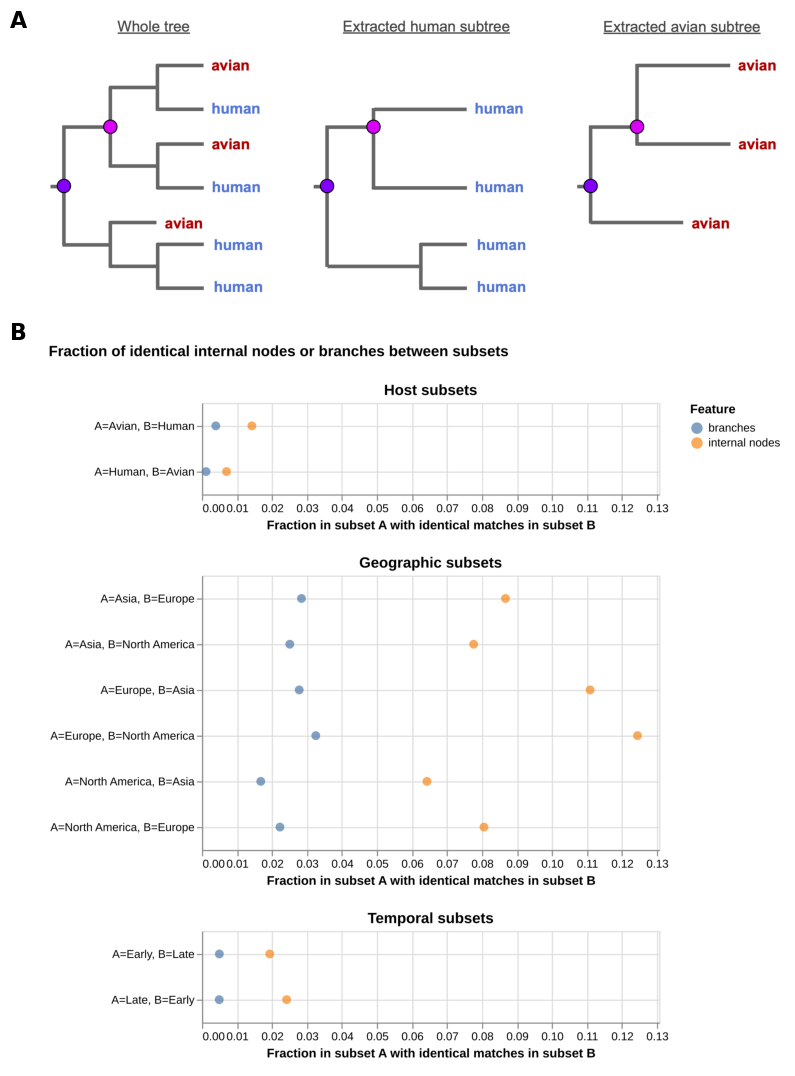

In [6]:
img_a = mpimg.imread("../results/figures/tree_extraction.png")
img_b = mpimg.imread("../results/figures/subset_pcp_overlap_aggregated.png")

# Set panel widths so both panels render at the same width in the figure.
# Height ratio follows from each image's aspect (height/width).
a_aspect = img_a.shape[0] / img_a.shape[1]
b_aspect = img_b.shape[0] / img_b.shape[1]

# Add a modest vertical gap above panel B for its label.
fig_width_in = 8
img_height_in = fig_width_in * (a_aspect + b_aspect)
label_gap_in = 0.175
fig_height_in = img_height_in + label_gap_in
hspace = label_gap_in / (img_height_in / 2)

fig = plt.figure(figsize=(fig_width_in, fig_height_in))
gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[a_aspect, b_aspect],
    hspace=hspace,
    left=0.05,
    right=0.98,
    top=0.98,
    bottom=0.02,
)

ax_a = fig.add_subplot(gs[0])
ax_a.imshow(img_a)
ax_a.axis("off")

ax_b = fig.add_subplot(gs[1])
ax_b.imshow(img_b)
ax_b.axis("off")

label_x = 0.01
pos_a = ax_a.get_position()
pos_b = ax_b.get_position()
fig.text(label_x, pos_a.y1, "A",
         fontsize=16, fontweight="bold", va="top", ha="left")
# Drop the "B" label slightly so it partially overlaps the top of panel B.
fig.text(label_x, pos_b.y1 - 0.005, "B",
         fontsize=16, fontweight="bold", va="bottom", ha="left")

plt.savefig(
    "../results/figures/subset_pcp_overlap_composite.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## subset_fitness_effects.png

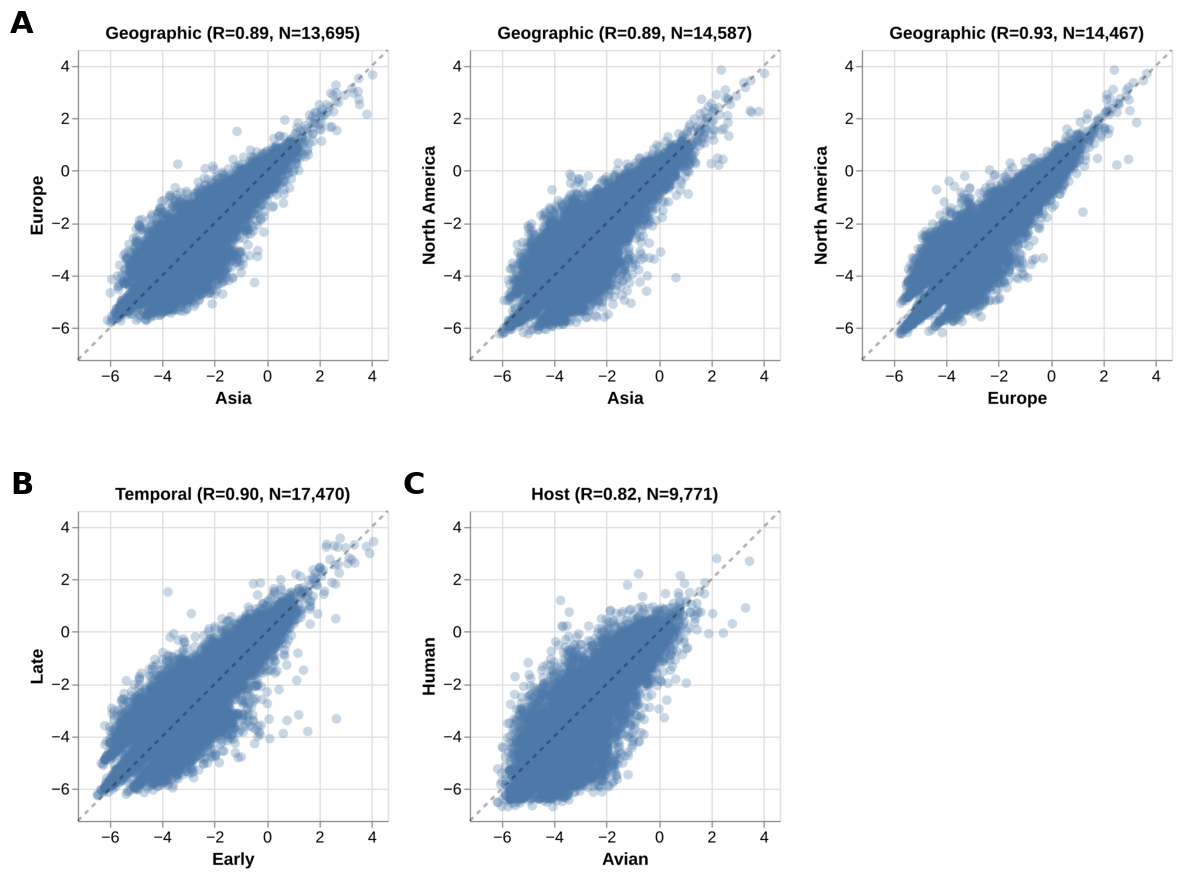

In [7]:
# 3-panel composite of subset fitness-effect scatter plots.
# Panel A (top row): three geographic comparisons.
# Panel B (bottom-left): temporal. Panel C (to the right of B): host.
# Columns are left-justified so the bottom row leaves the right-most
# column empty rather than centering the two plots.

fig_dir = "../results/figures"
geo_paths = [
    f"{fig_dir}/subset_fitness_scatter_geographic_asia_vs_europe.png",
    f"{fig_dir}/subset_fitness_scatter_geographic_asia_vs_north_america.png",
    f"{fig_dir}/subset_fitness_scatter_geographic_europe_vs_north_america.png",
]
temporal_path = f"{fig_dir}/subset_fitness_scatter_temporal_early_vs_late.png"
host_path = f"{fig_dir}/subset_fitness_scatter_host_avian_vs_human.png"

geo_imgs = [mpimg.imread(p) for p in geo_paths]
img_b = mpimg.imread(temporal_path)
img_c = mpimg.imread(host_path)

# All five panels come from the same Altair template, so they share aspect.
aspect = geo_imgs[0].shape[0] / geo_imgs[0].shape[1]

fig = plt.figure(figsize=(12, 12 * aspect * 2 / 3 * 1.1))
gs = gridspec.GridSpec(
    2, 3,
    hspace=0.15,
    wspace=0.05,
    left=0.025,
    right=0.99,
    top=0.95,
    bottom=0.02,
)

# Row 0: three geographic panels (A).
geo_axes = []
for i, img in enumerate(geo_imgs):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(img)
    ax.axis("off")
    geo_axes.append(ax)

# Row 1: B (temporal) on the left, C (host) next to it; third column empty.
ax_b = fig.add_subplot(gs[1, 0])
ax_b.imshow(img_b)
ax_b.axis("off")

ax_c = fig.add_subplot(gs[1, 1])
ax_c.imshow(img_c)
ax_c.axis("off")

# Panel labels A/B/C centered on each panel's left edge.
label_kwargs = dict(fontsize=22, fontweight="bold", va="top", ha="center")
pos_a = geo_axes[0].get_position()
pos_b = ax_b.get_position()
pos_c = ax_c.get_position()

fig.text(pos_a.x0, pos_a.y1 + 0.01, "A", **label_kwargs)
fig.text(pos_b.x0, pos_b.y1 + 0.01, "B", **label_kwargs)
fig.text(pos_c.x0, pos_c.y1 + 0.01, "C", **label_kwargs)

plt.savefig(
    f"{fig_dir}/subset_fitness_effects_composite.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()